        date   fwd_1y1y   fwd_5y5y  spread_5y5y_minus_1y1y  ipca_mom  \
0 2010-01-04  12.577656  13.648011                1.070356      0.41   
1 2010-01-05  12.532078  13.655328                1.123250      0.41   
2 2010-01-06  12.471913  13.703439                1.231526      0.41   
3 2010-01-07  12.458073  13.735637                1.277564      0.41   
4 2010-01-08  12.467929  13.652784                1.184855      0.41   

   ipca_12m  ipca_3m_saar release_date_x  ibc_br_sa_level release_date_y  ...  \
0  4.218494       3.78376     2009-12-10         91.29501     2009-12-15  ...   
1  4.218494       3.78376     2009-12-10         91.29501     2009-12-15  ...   
2  4.218494       3.78376     2009-12-10         91.29501     2009-12-15  ...   
3  4.218494       3.78376     2009-12-10         91.29501     2009-12-15  ...   
4  4.218494       3.78376     2009-12-10         91.29501     2009-12-15  ...   

  spread_chg_21d  ibc_br_sa_3m_change  spread_change_fwd_5d  \
0            NaN 

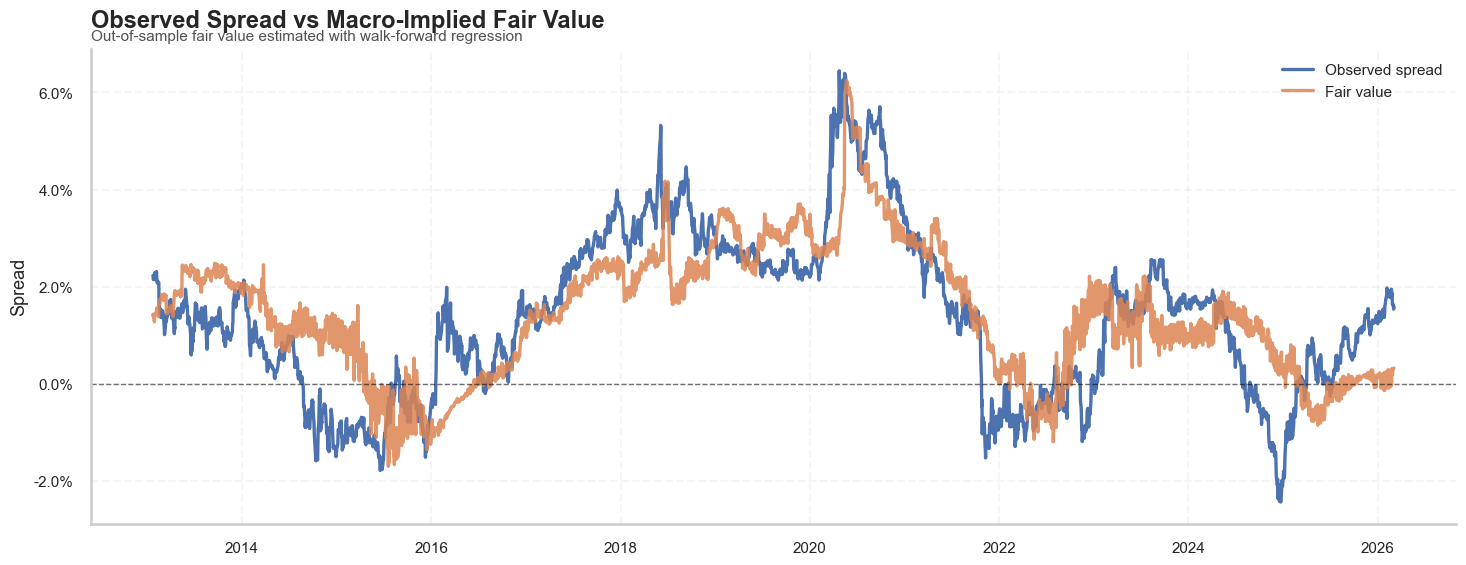

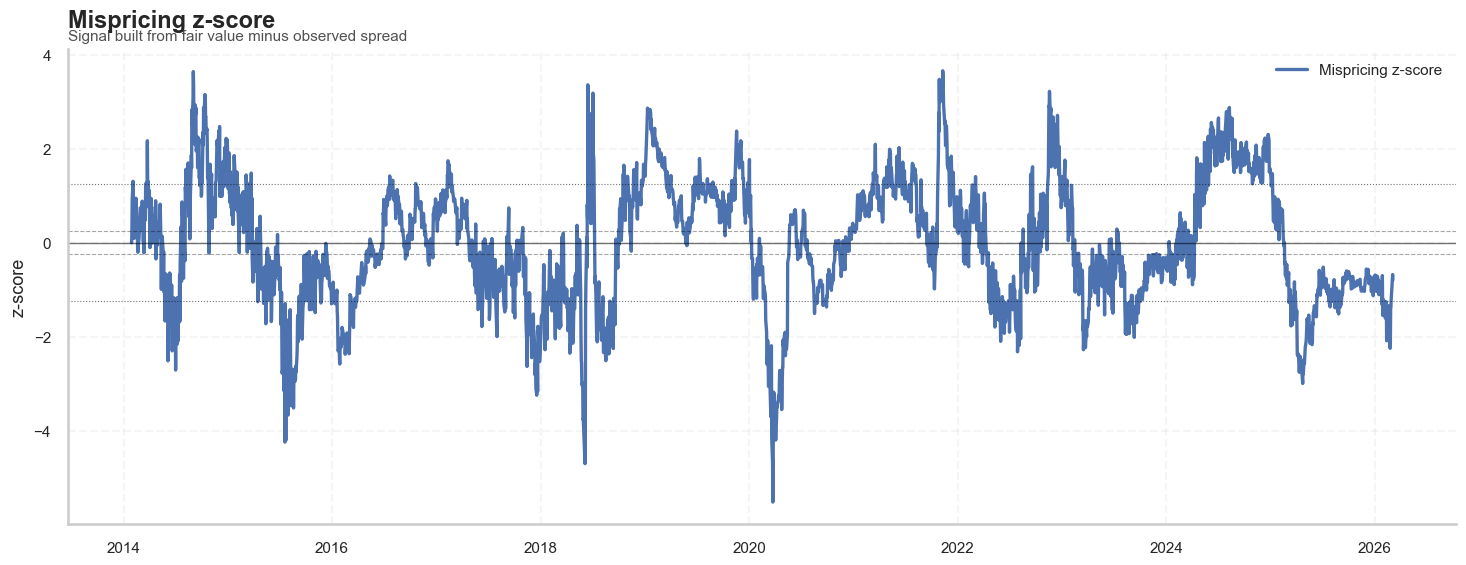

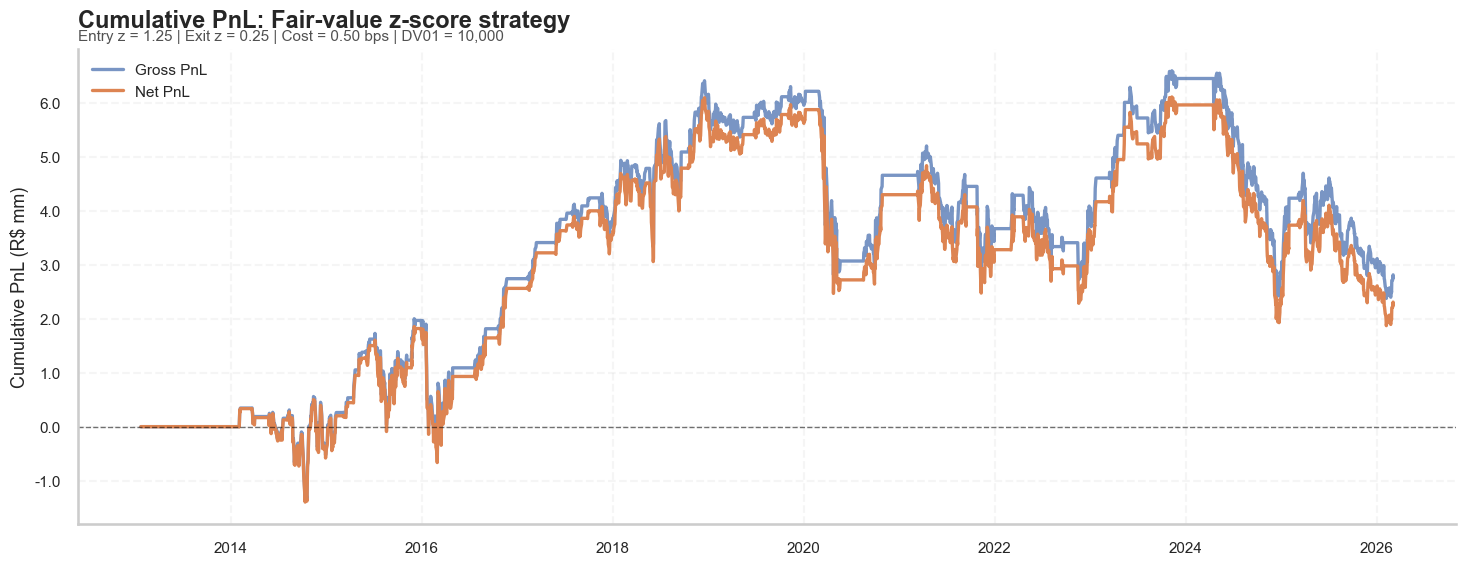

Saved: c:\Projetos\estudo_curva\figures\fig_14_drawdown_fair_value_zscore.png
Saved: c:\Projetos\estudo_curva\figures\fig_14_drawdown_fair_value_zscore.pdf


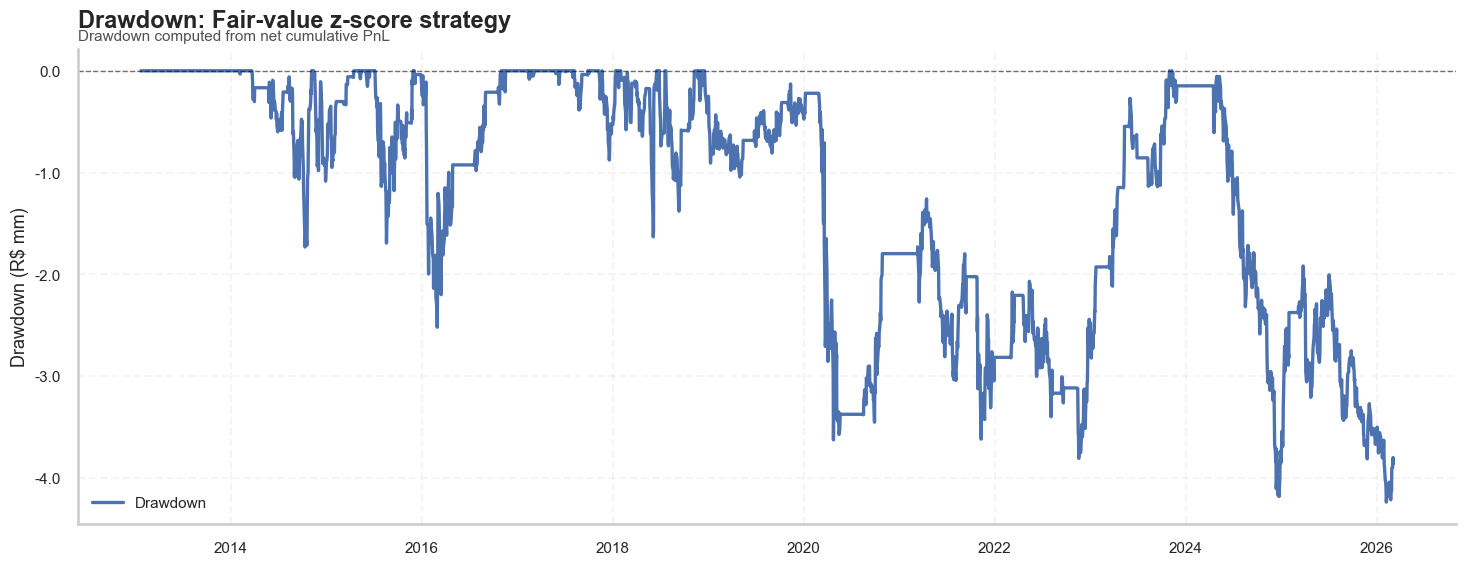

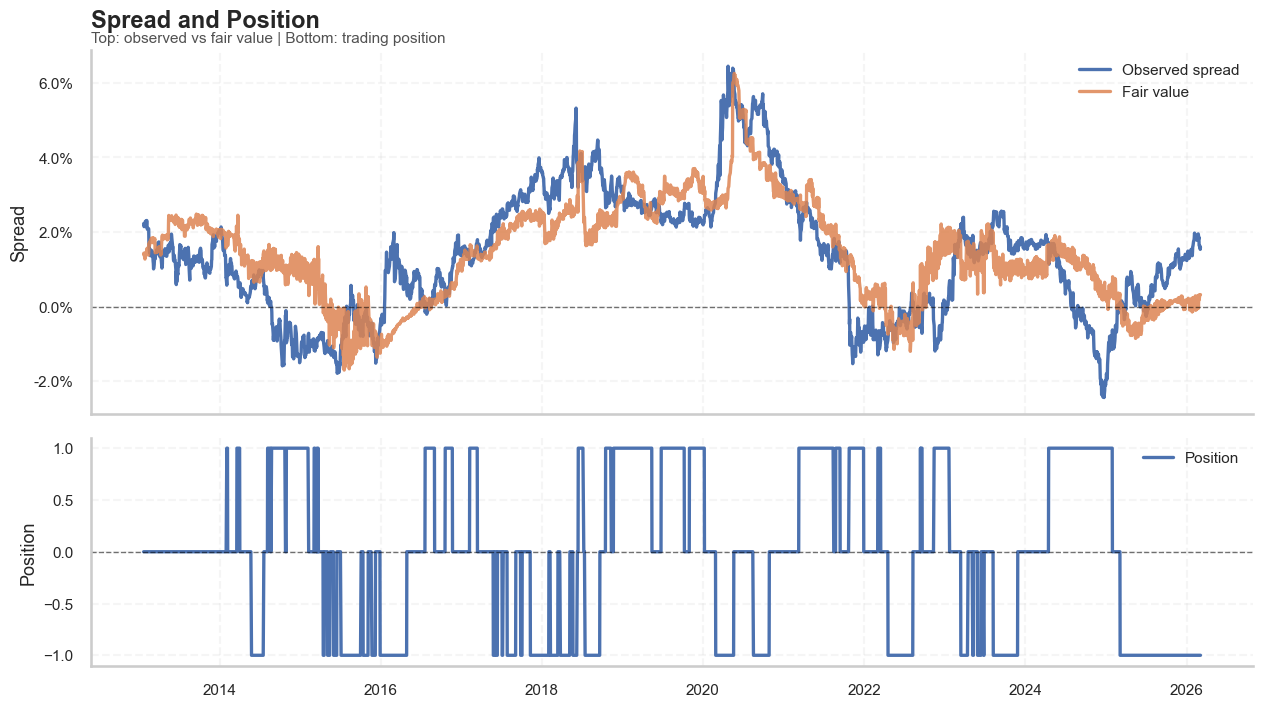

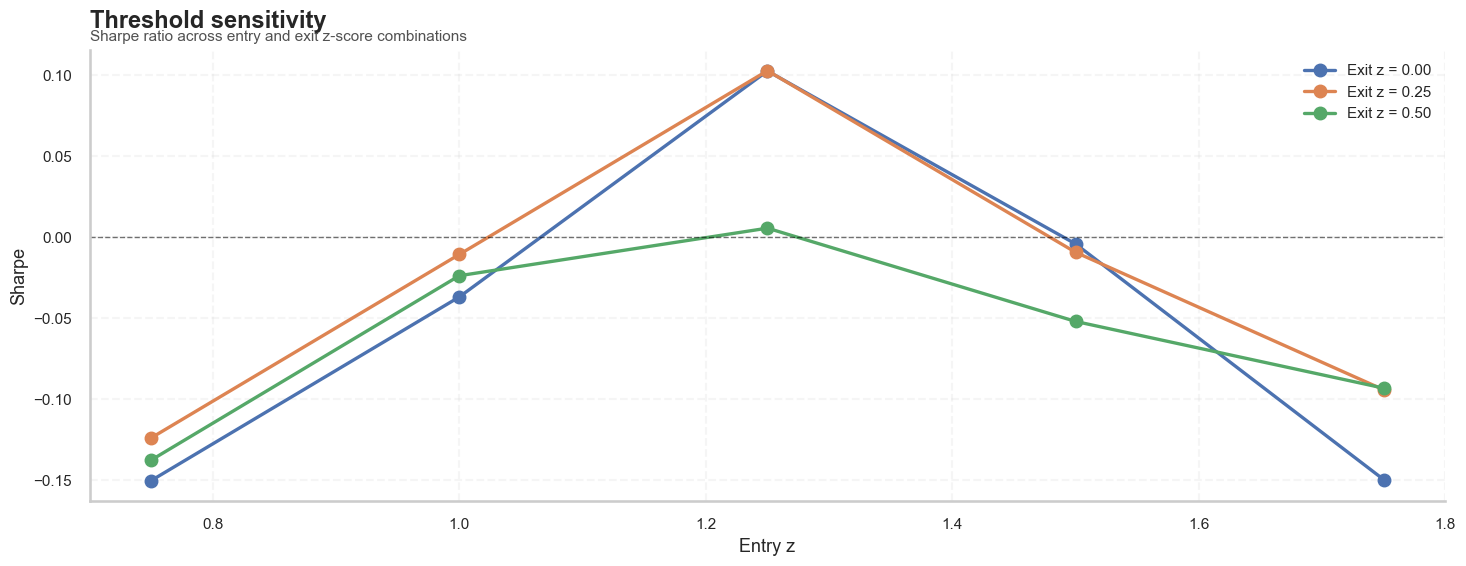

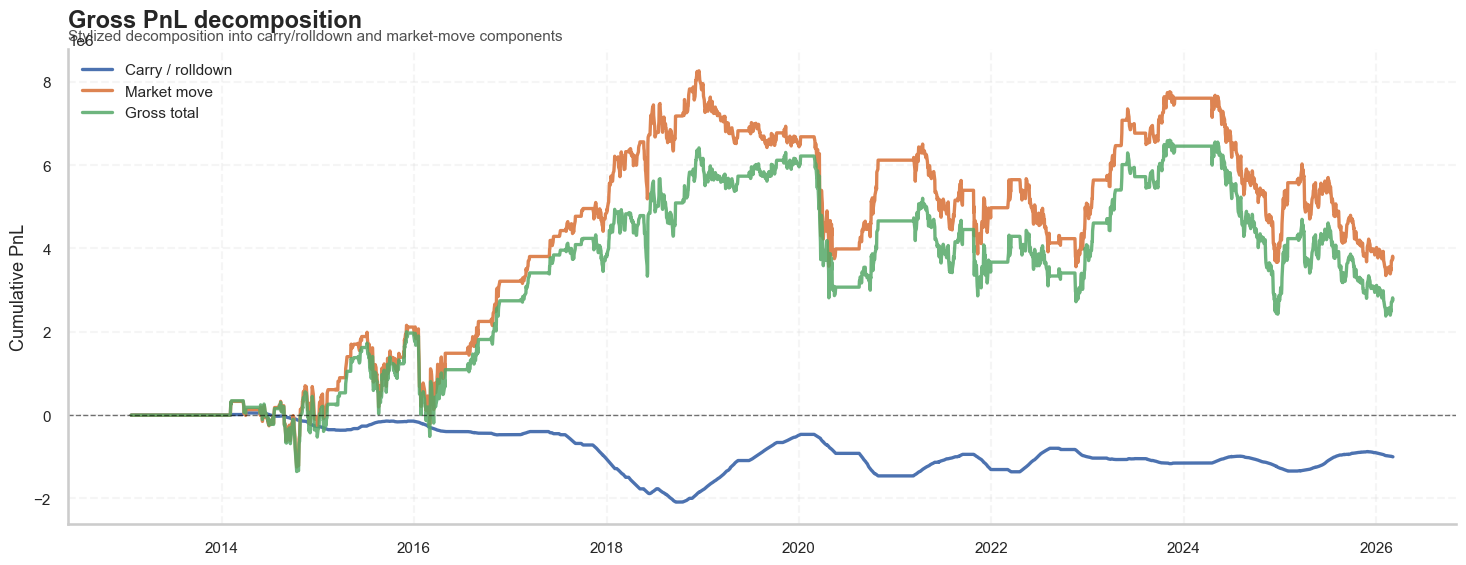

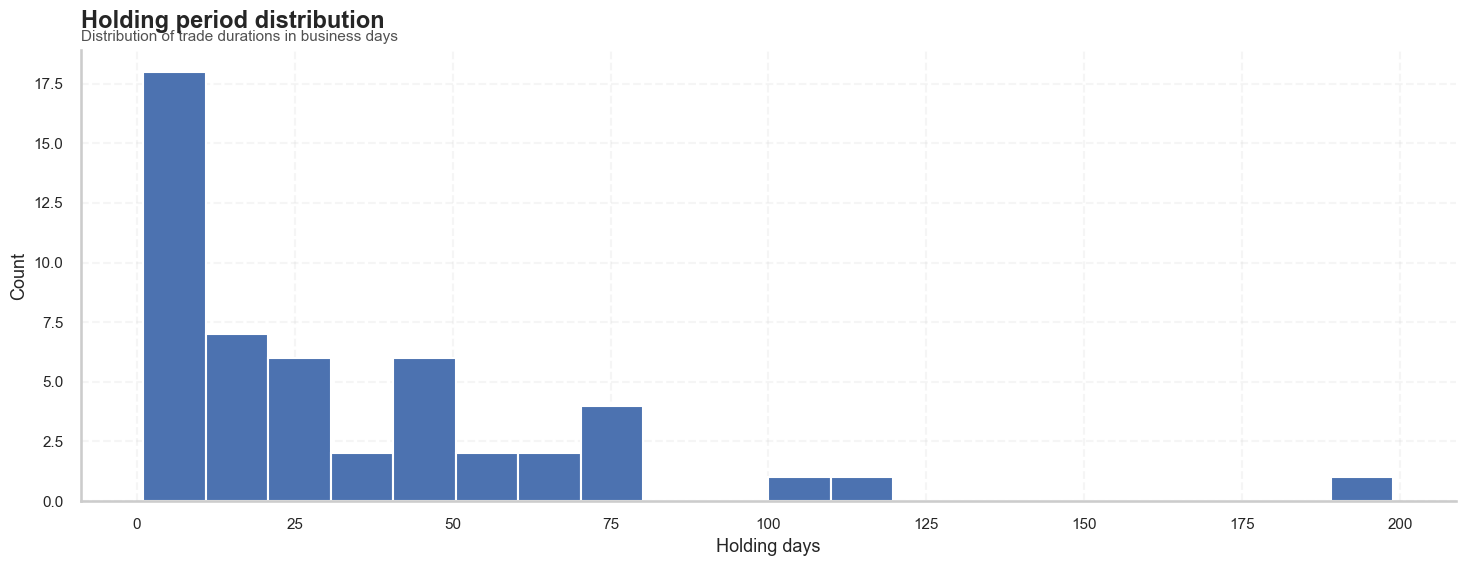


Saved files:
- c:\Projetos\estudo_curva\data_processed\fair_value_zscore_backtest.csv
- c:\Projetos\estudo_curva\data_processed\fair_value_zscore_trade_log.csv
- c:\Projetos\estudo_curva\tables\tab_07_fair_value_zscore_backtest_metrics.csv
- c:\Projetos\estudo_curva\tables\tab_08_fair_value_zscore_pnl_decomposition.csv
- c:\Projetos\estudo_curva\tables\tab_09_fair_value_zscore_yearly_metrics.csv
- c:\Projetos\estudo_curva\tables\tab_10_fair_value_zscore_trade_duration_summary.csv
- c:\Projetos\estudo_curva\tables\tab_11_fair_value_zscore_threshold_sensitivity.csv
- c:\Projetos\estudo_curva\tables\tab_12_fair_value_zscore_cost_sensitivity.csv
- c:\Projetos\estudo_curva\figures\fig_11_observed_vs_fair_value_zscore.png
- c:\Projetos\estudo_curva\figures\fig_12_mispricing_zscore.png
- c:\Projetos\estudo_curva\figures\fig_13_cumulative_pnl_fair_value_zscore.png
- c:\Projetos\estudo_curva\figures\fig_14_drawdown_fair_value_zscore.png
- c:\Projetos\estudo_curva\figures\fig_15_spread_and_posi

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import statsmodels.api as sm

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd()

DATA_PROCESSED_DIR = BASE_DIR / "data_processed"
TABLES_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

DATA_PROCESSED_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

INPUT_CSV = DATA_PROCESSED_DIR / "curve_macro_stat_ready.csv"
RAW_CURVE_CSV = BASE_DIR / "historico_txref.csv"

# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

TARGET_COL = "spread_5y5y_minus_1y1y"
MAIN_FACTOR = "inflation_expectations_gap"
OPTIONAL_CONTROL = "ibc_br_sa_level"

required = ["date", TARGET_COL, MAIN_FACTOR]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print(df.head())
print(df.tail())
print(df.columns.tolist())

# ------------------------------------------------------------
# 2) Load raw curve for stylized carry / rolldown decomposition
# ------------------------------------------------------------
raw_curve = pd.read_csv(RAW_CURVE_CSV, sep=";")
raw_curve["data_referencia"] = pd.to_datetime(raw_curve["data_referencia"], errors="coerce")
raw_curve["taxa"] = pd.to_numeric(raw_curve["taxa"], errors="coerce")
raw_curve["dias_corridos"] = pd.to_numeric(raw_curve["dias_corridos"], errors="coerce")

raw_curve = raw_curve[raw_curve["convencao_dias"] == 252].copy()
raw_curve = raw_curve[raw_curve["tipo_taxa"] == "APR"].copy()
raw_curve = raw_curve.dropna(subset=["data_referencia", "dias_corridos", "taxa"])
raw_curve = raw_curve.sort_values(["data_referencia", "dias_corridos"]).reset_index(drop=True)

curve_map = {}
for dt, grp in raw_curve.groupby("data_referencia"):
    tmp = grp[["dias_corridos", "taxa"]].drop_duplicates("dias_corridos").sort_values("dias_corridos")
    curve_map[pd.Timestamp(dt)] = {
        "curve_days": tmp["dias_corridos"].to_numpy(dtype=float),
        "curve_rates": tmp["taxa"].to_numpy(dtype=float),
    }

print(f"Loaded raw DI curve dates: {len(curve_map)}")

# ------------------------------------------------------------
# 3) Plot style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "lines.linewidth": 2.4,
    "savefig.dpi": 300,
})

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def setup_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")
    sns.despine(ax=ax)

def add_subtitle(ax, subtitle: str):
    ax.text(
        0.0, 1.02, subtitle,
        transform=ax.transAxes,
        fontsize=11,
        alpha=0.80
    )

# ------------------------------------------------------------
# 4) Helpers: save tables
# ------------------------------------------------------------
def save_table(
    df_table: pd.DataFrame,
    filename_stem: str,
    index: bool = False,
    rename_map: dict | None = None,
    value_maps: dict | None = None,
    float_fmt: str = "%.4f",
):
    csv_path = TABLES_DIR / f"{filename_stem}.csv"
    tex_path = TABLES_DIR / f"{filename_stem}.tex"

    out_csv = df_table.copy()
    out_csv.to_csv(csv_path, index=index)

    out_tex = df_table.copy()

    if value_maps:
        for col, mapper in value_maps.items():
            if col in out_tex.columns:
                out_tex[col] = out_tex[col].replace(mapper)

    if rename_map:
        out_tex = out_tex.rename(columns=rename_map)

    latex_str = out_tex.to_latex(
        index=index,
        escape=True,
        float_format=float_fmt,
        na_rep=""
    )
    tex_path.write_text(latex_str, encoding="utf-8")

# ------------------------------------------------------------
# 5) Parameters
# ------------------------------------------------------------
USE_CONTROL = True
TRAIN_WINDOW = 756        # ~3 business years
ZSCORE_WINDOW = 252       # ~1 business year
ENTRY_Z = 1.25
EXIT_Z = 0.25
DV01_POSITION = 10_000    # cash PnL per 1 bp move in the spread
TCOST_BPS = 0.50          # cost in bp of spread per 1 unit turnover
ANNUALIZATION = 252
BASIS = 252

FEATURE_COLS = [MAIN_FACTOR]
if USE_CONTROL and OPTIONAL_CONTROL in df.columns:
    FEATURE_COLS.append(OPTIONAL_CONTROL)

print("Feature columns:", FEATURE_COLS)

# ------------------------------------------------------------
# 6) Curve helpers for stylized carry / rolldown
# ------------------------------------------------------------
def annual_rate_to_discount_factor(rate_pct: np.ndarray, days: np.ndarray, basis: int = BASIS) -> np.ndarray:
    r = rate_pct / 100.0
    return 1.0 / ((1.0 + r) ** (days / basis))

def discount_factor_to_annual_rate(dfactor: np.ndarray, days: np.ndarray, basis: int = BASIS) -> np.ndarray:
    return (dfactor ** (-basis / days) - 1.0) * 100.0

def interpolate_zero_rates_from_curve(
    target_days: np.ndarray,
    curve_days: np.ndarray,
    curve_rates_pct: np.ndarray,
    basis: int = BASIS
) -> np.ndarray:
    curve_days = np.asarray(curve_days, dtype=float)
    curve_rates_pct = np.asarray(curve_rates_pct, dtype=float)

    tmp = (
        pd.DataFrame({"dias_corridos": curve_days, "taxa": curve_rates_pct})
        .drop_duplicates("dias_corridos")
        .sort_values("dias_corridos")
    )

    curve_days = tmp["dias_corridos"].to_numpy()
    curve_rates_pct = tmp["taxa"].to_numpy()

    dfs = annual_rate_to_discount_factor(curve_rates_pct, curve_days, basis=basis)
    target_dfs = np.interp(target_days, curve_days, dfs)

    return discount_factor_to_annual_rate(target_dfs, target_days, basis=basis)

def forward_rate(z1_pct: float, t1_days: int, z2_pct: float, t2_days: int, basis: int = BASIS) -> float:
    z1 = z1_pct / 100.0
    z2 = z2_pct / 100.0

    acc1 = (1.0 + z1) ** (t1_days / basis)
    acc2 = (1.0 + z2) ** (t2_days / basis)

    fwd = (acc2 / acc1) ** (basis / (t2_days - t1_days)) - 1.0
    return fwd * 100.0

def build_target_days_corridos(ref_date: pd.Timestamp) -> dict:
    d1 = ref_date + pd.DateOffset(years=1)
    d2 = ref_date + pd.DateOffset(years=2)
    d5 = ref_date + pd.DateOffset(years=5)
    d10 = ref_date + pd.DateOffset(years=10)

    return {
        "dc_1y": (d1 - ref_date).days,
        "dc_2y": (d2 - ref_date).days,
        "dc_5y": (d5 - ref_date).days,
        "dc_10y": (d10 - ref_date).days,
    }

def compute_spread_from_curve(curve_days, curve_rates, ref_date, roll_calendar_days=0):
    targets = build_target_days_corridos(ref_date)

    dc_1y = targets["dc_1y"] - roll_calendar_days
    dc_2y = targets["dc_2y"] - roll_calendar_days
    dc_5y = targets["dc_5y"] - roll_calendar_days
    dc_10y = targets["dc_10y"] - roll_calendar_days

    # Need strictly positive maturities
    if min(dc_1y, dc_2y, dc_5y, dc_10y) <= 1:
        return np.nan

    target_vertices = np.array([dc_1y, dc_2y, dc_5y, dc_10y], dtype=float)

    # Need curve coverage
    if curve_days.min() > target_vertices.min() or curve_days.max() < target_vertices.max():
        return np.nan

    interp_rates = interpolate_zero_rates_from_curve(
        target_days=target_vertices,
        curve_days=curve_days,
        curve_rates_pct=curve_rates,
        basis=BASIS
    )

    z_1y, z_2y, z_5y, z_10y = interp_rates

    fwd_1y1y = forward_rate(z_1y, int(dc_1y), z_2y, int(dc_2y), basis=BASIS)
    fwd_5y5y = forward_rate(z_5y, int(dc_5y), z_10y, int(dc_10y), basis=BASIS)

    spread = fwd_5y5y - fwd_1y1y
    return spread

def compute_next_period_rolldown_change(current_date: pd.Timestamp, next_date: pd.Timestamp) -> float:
    """
    Stylized carry / rolldown:
    - uses today's curve only
    - rolls maturities down by the number of calendar days until the next observation
    - keeps the curve otherwise unchanged

    Returns the predicted spread change (percentage points) from t to t+1
    due solely to the passage of time.
    """
    if current_date not in curve_map:
        return np.nan

    curve_days = curve_map[current_date]["curve_days"]
    curve_rates = curve_map[current_date]["curve_rates"]

    roll_calendar_days = int((next_date - current_date).days)
    if roll_calendar_days <= 0:
        return np.nan

    current_spread = compute_spread_from_curve(curve_days, curve_rates, current_date, roll_calendar_days=0)
    rolled_spread = compute_spread_from_curve(curve_days, curve_rates, current_date, roll_calendar_days=roll_calendar_days)

    if pd.isna(current_spread) or pd.isna(rolled_spread):
        return np.nan

    return rolled_spread - current_spread

# ------------------------------------------------------------
# 7) Walk-forward fair value estimation
# ------------------------------------------------------------
def safe_zscore(train_series: pd.Series, x_value: float):
    mu = train_series.mean(skipna=True)
    sigma = train_series.std(skipna=True)
    if pd.isna(sigma) or sigma == 0:
        return np.nan
    return (x_value - mu) / sigma

def build_walk_forward_fair_value(
    data: pd.DataFrame,
    target_col: str,
    feature_cols: list[str],
    train_window: int
) -> pd.DataFrame:
    rows = []

    work = data[["date", target_col] + feature_cols].copy()

    for i in range(train_window, len(work)):
        train = work.iloc[i-train_window:i].copy()
        test_row = work.iloc[i].copy()

        train = train.dropna(subset=[target_col] + feature_cols)
        if len(train) < int(0.8 * train_window):
            rows.append({
                "date": test_row["date"],
                "spread_obs": test_row[target_col],
                "fair_value": np.nan,
                "mispricing": np.nan,
                "n_train": len(train),
            })
            continue

        X_train = pd.DataFrame(index=train.index)
        X_test = {}

        for col in feature_cols:
            sigma = train[col].std()
            if pd.isna(sigma) or sigma == 0:
                z_train = pd.Series(np.nan, index=train.index)
                z_test = np.nan
            else:
                z_train = (train[col] - train[col].mean()) / sigma
                z_test = safe_zscore(train[col], test_row[col])

            X_train[f"{col}_z"] = z_train
            X_test[f"{col}_z"] = z_test

        X_train = sm.add_constant(X_train)
        y_train = train[target_col]

        if any(pd.isna(v) for v in X_test.values()):
            rows.append({
                "date": test_row["date"],
                "spread_obs": test_row[target_col],
                "fair_value": np.nan,
                "mispricing": np.nan,
                "n_train": len(train),
            })
            continue

        X_test = pd.DataFrame([X_test])
        X_test = sm.add_constant(X_test, has_constant="add")

        try:
            model = sm.OLS(y_train, X_train).fit()
            fair_value = float(model.predict(X_test).iloc[0])
        except Exception:
            fair_value = np.nan

        spread_obs = test_row[target_col]
        mispricing = fair_value - spread_obs if pd.notna(fair_value) and pd.notna(spread_obs) else np.nan

        rows.append({
            "date": test_row["date"],
            "spread_obs": spread_obs,
            "fair_value": fair_value,
            "mispricing": mispricing,
            "n_train": len(train),
        })

    return pd.DataFrame(rows)

fair_df = build_walk_forward_fair_value(
    data=df,
    target_col=TARGET_COL,
    feature_cols=FEATURE_COLS,
    train_window=TRAIN_WINDOW
)

print(fair_df.head())
print(fair_df.tail())
print(fair_df.shape)

# ------------------------------------------------------------
# 8) Rolling z-score of mispricing (strictly backward-looking)
# ------------------------------------------------------------
fair_df["mispricing_mean_roll"] = fair_df["mispricing"].rolling(ZSCORE_WINDOW).mean().shift(1)
fair_df["mispricing_std_roll"] = fair_df["mispricing"].rolling(ZSCORE_WINDOW).std().shift(1)
fair_df["mispricing_z"] = (
    (fair_df["mispricing"] - fair_df["mispricing_mean_roll"]) /
    fair_df["mispricing_std_roll"]
)

# ------------------------------------------------------------
# 9) Trading rule
# ------------------------------------------------------------
def build_position_from_zscore(z: pd.Series, entry_z: float, exit_z: float) -> pd.Series:
    pos = []
    prev = 0.0

    for val in z:
        if pd.isna(val):
            pos.append(0.0)
            prev = 0.0
            continue

        if prev == 0.0:
            if val >= entry_z:
                prev = 1.0
            elif val <= -entry_z:
                prev = -1.0
            else:
                prev = 0.0

        elif prev > 0.0:
            if val <= -entry_z:
                prev = -1.0
            elif val <= exit_z:
                prev = 0.0
            else:
                prev = 1.0

        elif prev < 0.0:
            if val >= entry_z:
                prev = 1.0
            elif val >= -exit_z:
                prev = 0.0
            else:
                prev = -1.0

        pos.append(prev)

    return pd.Series(pos, index=z.index)

fair_df["position"] = build_position_from_zscore(
    fair_df["mispricing_z"],
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z
)

# ------------------------------------------------------------
# 10) Stylized carry / rolldown decomposition
# ------------------------------------------------------------
fair_df["next_date"] = fair_df["date"].shift(-1)
fair_df["calendar_days_to_next"] = (fair_df["next_date"] - fair_df["date"]).dt.days

rolldown_changes = [np.nan]  # aligned to the realized change row (t -> t+1 lives on row t+1)
for i in range(len(fair_df) - 1):
    current_date = pd.Timestamp(fair_df["date"].iloc[i])
    next_date = pd.Timestamp(fair_df["date"].iloc[i + 1])

    rd = compute_next_period_rolldown_change(current_date, next_date)
    rolldown_changes.append(rd)

fair_df["rolldown_change_1d"] = rolldown_changes
fair_df["spread_change_1d"] = fair_df["spread_obs"].diff()
fair_df["market_move_change_1d"] = fair_df["spread_change_1d"] - fair_df["rolldown_change_1d"]

# ------------------------------------------------------------
# 11) PnL construction at 10k DV01
# ------------------------------------------------------------
# spread_change_1d is in percentage points:
# 0.01 percentage points = 1 bp
fair_df["spread_change_1d_bps"] = fair_df["spread_change_1d"] * 100.0
fair_df["rolldown_change_1d_bps"] = fair_df["rolldown_change_1d"] * 100.0
fair_df["market_move_change_1d_bps"] = fair_df["market_move_change_1d"] * 100.0

fair_df["position_lag1"] = fair_df["position"].shift(1).fillna(0.0)

fair_df["gross_pnl"] = (
    fair_df["position_lag1"] *
    fair_df["spread_change_1d_bps"] *
    DV01_POSITION
)

fair_df["carry_rolldown_pnl"] = (
    fair_df["position_lag1"] *
    fair_df["rolldown_change_1d_bps"] *
    DV01_POSITION
)

fair_df["market_move_pnl"] = (
    fair_df["position_lag1"] *
    fair_df["market_move_change_1d_bps"] *
    DV01_POSITION
)

fair_df["turnover"] = fair_df["position"].diff().abs().fillna(0.0)

fair_df["transaction_cost"] = (
    fair_df["turnover"] *
    TCOST_BPS *
    DV01_POSITION
)

fair_df["net_pnl"] = fair_df["gross_pnl"] - fair_df["transaction_cost"]

fair_df["equity_gross"] = fair_df["gross_pnl"].cumsum()
fair_df["equity_net"] = fair_df["net_pnl"].cumsum()

fair_df["carry_rolldown_equity"] = fair_df["carry_rolldown_pnl"].cumsum()
fair_df["market_move_equity"] = fair_df["market_move_pnl"].cumsum()

fair_df["running_max"] = fair_df["equity_net"].cummax()
fair_df["drawdown"] = fair_df["equity_net"] - fair_df["running_max"]

# ------------------------------------------------------------
# 12) Performance metrics
# ------------------------------------------------------------
def compute_perf_metrics(backtest_df: pd.DataFrame, pnl_col: str = "net_pnl") -> dict:
    x = backtest_df[pnl_col].dropna().copy()

    if len(x) < 20:
        return {
            "nobs": len(x),
            "total_pnl": np.nan,
            "mean_daily_pnl": np.nan,
            "vol_daily_pnl": np.nan,
            "annualized_pnl": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "avg_abs_position": np.nan,
            "annual_turnover": np.nan,
            "hit_ratio": np.nan,
        }

    mean_daily = x.mean()
    vol_daily = x.std()
    annualized_pnl = mean_daily * ANNUALIZATION
    annualized_vol = vol_daily * np.sqrt(ANNUALIZATION)
    sharpe = annualized_pnl / annualized_vol if annualized_vol > 0 else np.nan

    max_dd = backtest_df["drawdown"].min()
    avg_abs_position = backtest_df["position"].abs().mean()
    annual_turnover = backtest_df["turnover"].sum() / (len(backtest_df) / ANNUALIZATION)
    hit_ratio = (x > 0).mean()

    return {
        "nobs": len(x),
        "total_pnl": x.sum(),
        "mean_daily_pnl": mean_daily,
        "vol_daily_pnl": vol_daily,
        "annualized_pnl": annualized_pnl,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "avg_abs_position": avg_abs_position,
        "annual_turnover": annual_turnover,
        "hit_ratio": hit_ratio,
    }

metrics = compute_perf_metrics(fair_df, pnl_col="net_pnl")
metrics_table = pd.DataFrame([metrics])

save_table(
    metrics_table,
    "tab_07_fair_value_zscore_backtest_metrics",
    index=False,
    rename_map={
        "nobs": "Obs.",
        "total_pnl": "Total PnL",
        "mean_daily_pnl": "Mean daily PnL",
        "vol_daily_pnl": "Daily vol",
        "annualized_pnl": "Annualized PnL",
        "annualized_vol": "Annualized vol",
        "sharpe": "Sharpe",
        "max_drawdown": "Max drawdown",
        "avg_abs_position": "Avg |position|",
        "annual_turnover": "Annual turnover",
        "hit_ratio": "Hit ratio",
    },
    float_fmt="%.2f"
)

# ------------------------------------------------------------
# 13) Carry / rolldown decomposition summary
# ------------------------------------------------------------
decomp_table = pd.DataFrame([{
    "gross_pnl": fair_df["gross_pnl"].sum(),
    "carry_rolldown_pnl": fair_df["carry_rolldown_pnl"].sum(),
    "market_move_pnl": fair_df["market_move_pnl"].sum(),
    "transaction_cost": fair_df["transaction_cost"].sum(),
    "net_pnl": fair_df["net_pnl"].sum(),
    "carry_share_of_gross": fair_df["carry_rolldown_pnl"].sum() / fair_df["gross_pnl"].sum() if fair_df["gross_pnl"].sum() != 0 else np.nan,
    "market_share_of_gross": fair_df["market_move_pnl"].sum() / fair_df["gross_pnl"].sum() if fair_df["gross_pnl"].sum() != 0 else np.nan,
}])

save_table(
    decomp_table,
    "tab_08_fair_value_zscore_pnl_decomposition",
    index=False,
    rename_map={
        "gross_pnl": "Gross PnL",
        "carry_rolldown_pnl": "Carry / rolldown PnL",
        "market_move_pnl": "Market-move PnL",
        "transaction_cost": "Transaction cost",
        "net_pnl": "Net PnL",
        "carry_share_of_gross": "Carry share of gross",
        "market_share_of_gross": "Market share of gross",
    },
    float_fmt="%.4f"
)

# ------------------------------------------------------------
# 14) Yearly performance
# ------------------------------------------------------------
yearly = fair_df.copy()
yearly["year"] = yearly["date"].dt.year

yearly_rows = []
for year, grp in yearly.groupby("year"):
    if grp["net_pnl"].notna().sum() < 20:
        continue

    m = compute_perf_metrics(grp, pnl_col="net_pnl")
    yearly_rows.append({
        "year": year,
        **m
    })

yearly_table = pd.DataFrame(yearly_rows)

save_table(
    yearly_table,
    "tab_09_fair_value_zscore_yearly_metrics",
    index=False,
    rename_map={
        "year": "Year",
        "nobs": "Obs.",
        "total_pnl": "Total PnL",
        "mean_daily_pnl": "Mean daily PnL",
        "vol_daily_pnl": "Daily vol",
        "annualized_pnl": "Annualized PnL",
        "annualized_vol": "Annualized vol",
        "sharpe": "Sharpe",
        "max_drawdown": "Max drawdown",
        "avg_abs_position": "Avg |position|",
        "annual_turnover": "Annual turnover",
        "hit_ratio": "Hit ratio",
    },
    float_fmt="%.2f"
)

# ------------------------------------------------------------
# 15) Trade log and holding-period analysis
# ------------------------------------------------------------
def build_trade_log(bt: pd.DataFrame) -> pd.DataFrame:
    trades = []

    current_side = 0.0
    entry_idx = None
    entry_date = None
    entry_z = None

    for i in range(len(bt)):
        pos = bt["position"].iloc[i]
        dt = bt["date"].iloc[i]

        if current_side == 0.0 and pos != 0.0:
            current_side = pos
            entry_idx = i
            entry_date = dt
            entry_z = bt["mispricing_z"].iloc[i]

        elif current_side != 0.0 and pos == 0.0:
            exit_idx = i
            exit_date = dt
            exit_z = bt["mispricing_z"].iloc[i]

            trade_slice = bt.iloc[entry_idx:exit_idx+1].copy()

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "side": "Long spread" if current_side > 0 else "Short spread",
                "holding_days": len(trade_slice) - 1,
                "holding_calendar_days": (pd.Timestamp(exit_date) - pd.Timestamp(entry_date)).days,
                "entry_z": entry_z,
                "exit_z": exit_z,
                "gross_pnl": trade_slice["gross_pnl"].sum(),
                "carry_rolldown_pnl": trade_slice["carry_rolldown_pnl"].sum(),
                "market_move_pnl": trade_slice["market_move_pnl"].sum(),
                "transaction_cost": trade_slice["transaction_cost"].sum(),
                "net_pnl": trade_slice["net_pnl"].sum(),
                "max_drawdown_trade": (
                    trade_slice["net_pnl"].cumsum() -
                    trade_slice["net_pnl"].cumsum().cummax()
                ).min(),
            })

            current_side = 0.0
            entry_idx = None
            entry_date = None
            entry_z = None

        elif current_side != 0.0 and pos != 0.0 and np.sign(pos) != np.sign(current_side):
            exit_idx = i
            exit_date = dt
            exit_z = bt["mispricing_z"].iloc[i]

            trade_slice = bt.iloc[entry_idx:exit_idx+1].copy()

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "side": "Long spread" if current_side > 0 else "Short spread",
                "holding_days": len(trade_slice) - 1,
                "holding_calendar_days": (pd.Timestamp(exit_date) - pd.Timestamp(entry_date)).days,
                "entry_z": entry_z,
                "exit_z": exit_z,
                "gross_pnl": trade_slice["gross_pnl"].sum(),
                "carry_rolldown_pnl": trade_slice["carry_rolldown_pnl"].sum(),
                "market_move_pnl": trade_slice["market_move_pnl"].sum(),
                "transaction_cost": trade_slice["transaction_cost"].sum(),
                "net_pnl": trade_slice["net_pnl"].sum(),
                "max_drawdown_trade": (
                    trade_slice["net_pnl"].cumsum() -
                    trade_slice["net_pnl"].cumsum().cummax()
                ).min(),
            })

            current_side = pos
            entry_idx = i
            entry_date = dt
            entry_z = bt["mispricing_z"].iloc[i]

    return pd.DataFrame(trades)

trade_log = build_trade_log(fair_df)
trade_log.to_csv(DATA_PROCESSED_DIR / "fair_value_zscore_trade_log.csv", index=False)

trade_duration_summary = pd.DataFrame([{
    "number_of_trades": len(trade_log),
    "avg_holding_days": trade_log["holding_days"].mean() if len(trade_log) else np.nan,
    "median_holding_days": trade_log["holding_days"].median() if len(trade_log) else np.nan,
    "min_holding_days": trade_log["holding_days"].min() if len(trade_log) else np.nan,
    "max_holding_days": trade_log["holding_days"].max() if len(trade_log) else np.nan,
    "avg_holding_calendar_days": trade_log["holding_calendar_days"].mean() if len(trade_log) else np.nan,
    "median_holding_calendar_days": trade_log["holding_calendar_days"].median() if len(trade_log) else np.nan,
    "pct_profitable_trades": (trade_log["net_pnl"] > 0).mean() if len(trade_log) else np.nan,
    "avg_net_pnl_per_trade": trade_log["net_pnl"].mean() if len(trade_log) else np.nan,
    "median_net_pnl_per_trade": trade_log["net_pnl"].median() if len(trade_log) else np.nan,
}])

save_table(
    trade_duration_summary,
    "tab_10_fair_value_zscore_trade_duration_summary",
    index=False,
    rename_map={
        "number_of_trades": "Number of trades",
        "avg_holding_days": "Avg holding days",
        "median_holding_days": "Median holding days",
        "min_holding_days": "Min holding days",
        "max_holding_days": "Max holding days",
        "avg_holding_calendar_days": "Avg holding cal days",
        "median_holding_calendar_days": "Median holding cal days",
        "pct_profitable_trades": "Profitable trades",
        "avg_net_pnl_per_trade": "Avg net PnL / trade",
        "median_net_pnl_per_trade": "Median net PnL / trade",
    },
    float_fmt="%.2f"
)

# ------------------------------------------------------------
# 16) Threshold sensitivity
# ------------------------------------------------------------
def run_strategy_with_thresholds(
    data: pd.DataFrame,
    entry_z: float,
    exit_z: float,
    tcost_bps: float,
    dv01_position: float
) -> dict:
    bt = data.copy()

    bt["position_tmp"] = build_position_from_zscore(bt["mispricing_z"], entry_z, exit_z)
    bt["position_lag1_tmp"] = bt["position_tmp"].shift(1).fillna(0.0)
    bt["gross_pnl_tmp"] = bt["position_lag1_tmp"] * bt["spread_change_1d_bps"] * dv01_position
    bt["carry_rolldown_pnl_tmp"] = bt["position_lag1_tmp"] * bt["rolldown_change_1d_bps"] * dv01_position
    bt["market_move_pnl_tmp"] = bt["position_lag1_tmp"] * bt["market_move_change_1d_bps"] * dv01_position
    bt["turnover_tmp"] = bt["position_tmp"].diff().abs().fillna(0.0)
    bt["cost_tmp"] = bt["turnover_tmp"] * tcost_bps * dv01_position
    bt["net_pnl_tmp"] = bt["gross_pnl_tmp"] - bt["cost_tmp"]
    bt["equity_tmp"] = bt["net_pnl_tmp"].cumsum()
    bt["running_max_tmp"] = bt["equity_tmp"].cummax()
    bt["drawdown_tmp"] = bt["equity_tmp"] - bt["running_max_tmp"]

    x = bt["net_pnl_tmp"].dropna()
    if len(x) < 20:
        return {
            "entry_z": entry_z,
            "exit_z": exit_z,
            "nobs": len(x),
            "annualized_pnl": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "annual_turnover": np.nan,
        }

    mean_daily = x.mean()
    vol_daily = x.std()
    ann_pnl = mean_daily * ANNUALIZATION
    ann_vol = vol_daily * np.sqrt(ANNUALIZATION)
    sharpe = ann_pnl / ann_vol if ann_vol > 0 else np.nan
    max_dd = bt["drawdown_tmp"].min()
    annual_turnover = bt["turnover_tmp"].sum() / (len(bt) / ANNUALIZATION)

    return {
        "entry_z": entry_z,
        "exit_z": exit_z,
        "nobs": len(x),
        "annualized_pnl": ann_pnl,
        "annualized_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
        "annual_turnover": annual_turnover,
    }

threshold_rows = []
for entry_z in [0.75, 1.00, 1.25, 1.50, 1.75]:
    for exit_z in [0.00, 0.25, 0.50]:
        if exit_z >= entry_z:
            continue
        threshold_rows.append(
            run_strategy_with_thresholds(
                fair_df,
                entry_z=entry_z,
                exit_z=exit_z,
                tcost_bps=TCOST_BPS,
                dv01_position=DV01_POSITION
            )
        )

threshold_table = pd.DataFrame(threshold_rows).sort_values(
    ["sharpe", "annualized_pnl"],
    ascending=[False, False]
).reset_index(drop=True)

threshold_table_report = threshold_table.copy()

threshold_table_report["annualized_pnl_k"] = threshold_table_report["annualized_pnl"] / 1e3
threshold_table_report["annualized_vol_k"] = threshold_table_report["annualized_vol"] / 1e3
threshold_table_report["max_drawdown_k"] = threshold_table_report["max_drawdown"] / 1e3

threshold_table_report = threshold_table_report[[
    "entry_z",
    "exit_z",
    "nobs",
    "annualized_pnl_k",
    "annualized_vol_k",
    "sharpe",
    "max_drawdown_k",
    "annual_turnover",
]]

save_table(
    threshold_table_report,
    "tab_11_fair_value_zscore_threshold_sensitivity",
    index=False,
    rename_map={
        "entry_z": "Entry z",
        "exit_z": "Exit z",
        "nobs": "Obs.",
        "annualized_pnl_k": "Ann. PnL (R$ k)",
        "annualized_vol_k": "Ann. vol (R$ k)",
        "sharpe": "Sharpe",
        "max_drawdown_k": "Max DD (R$ k)",
        "annual_turnover": "Turnover",
    },
    float_fmt="%.1f"
)

# ------------------------------------------------------------
# 17) Cost sensitivity
# ------------------------------------------------------------
cost_rows = []
for tcost in [0.00, 0.25, 0.50, 0.75, 1.00, 1.50]:
    res = run_strategy_with_thresholds(
        fair_df,
        entry_z=ENTRY_Z,
        exit_z=EXIT_Z,
        tcost_bps=tcost,
        dv01_position=DV01_POSITION
    )
    res["tcost_bps"] = tcost
    cost_rows.append(res)

cost_table = pd.DataFrame(cost_rows)[[
    "tcost_bps", "nobs", "annualized_pnl", "annualized_vol",
    "sharpe", "max_drawdown", "annual_turnover"
]]

save_table(
    cost_table,
    "tab_12_fair_value_zscore_cost_sensitivity",
    index=False,
    rename_map={
        "tcost_bps": "Cost (bps)",
        "nobs": "Obs.",
        "annualized_pnl": "Annualized PnL",
        "annualized_vol": "Annualized vol",
        "sharpe": "Sharpe",
        "max_drawdown": "Max drawdown",
        "annual_turnover": "Annual turnover",
    },
    float_fmt="%.2f"
)

# ------------------------------------------------------------
# 18) Save enriched backtest dataset
# ------------------------------------------------------------
fair_df.to_csv(DATA_PROCESSED_DIR / "fair_value_zscore_backtest.csv", index=False)

# ------------------------------------------------------------
# 19) Plots
# ------------------------------------------------------------
# Fair value vs observed spread
fig, ax = plt.subplots()
plot_df = fair_df.dropna(subset=["spread_obs", "fair_value"]).copy()

ax.plot(plot_df["date"], plot_df["spread_obs"], label="Observed spread")
ax.plot(plot_df["date"], plot_df["fair_value"], label="Fair value", alpha=0.85)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Observed Spread vs Macro-Implied Fair Value", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Out-of-sample fair value estimated with walk-forward regression")
ax.set_ylabel("Spread")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
setup_time_axis(ax)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_11_observed_vs_fair_value_zscore.png", bbox_inches="tight")
plt.show()

# Mispricing z-score
fig, ax = plt.subplots()

plot_df = fair_df.dropna(subset=["mispricing_z"]).copy()
ax.plot(plot_df["date"], plot_df["mispricing_z"], label="Mispricing z-score")
ax.axhline(ENTRY_Z, color="black", linewidth=0.8, linestyle=":", alpha=0.55)
ax.axhline(-ENTRY_Z, color="black", linewidth=0.8, linestyle=":", alpha=0.55)
ax.axhline(EXIT_Z, color="black", linewidth=0.8, linestyle="--", alpha=0.35)
ax.axhline(-EXIT_Z, color="black", linewidth=0.8, linestyle="--", alpha=0.35)
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="-", alpha=0.55)

ax.set_title("Mispricing z-score", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Signal built from fair value minus observed spread")
ax.set_ylabel("z-score")
setup_time_axis(ax)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_12_mispricing_zscore.png", bbox_inches="tight")
plt.show()

# Cumulative PnL
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots()

plot_df = fair_df.dropna(subset=["equity_net"]).copy()
ax.plot(plot_df["date"], plot_df["equity_gross"] / 1e6, label="Gross PnL", alpha=0.75)
ax.plot(plot_df["date"], plot_df["equity_net"] / 1e6, label="Net PnL")

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Cumulative PnL: Fair-value z-score strategy", loc="left", pad=16, fontweight="bold")
add_subtitle(
    ax,
    f"Entry z = {ENTRY_Z:.2f} | Exit z = {EXIT_Z:.2f} | Cost = {TCOST_BPS:.2f} bps | DV01 = {DV01_POSITION:,.0f}"
)
ax.set_ylabel("Cumulative PnL (R$ mm)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.1f}"))
setup_time_axis(ax)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_13_cumulative_pnl_fair_value_zscore.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_13_cumulative_pnl_fair_value_zscore.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Drawdown
fig, ax = plt.subplots()

plot_df = fair_df.dropna(subset=["drawdown"]).copy()

# converter para milhões
ax.plot(plot_df["date"], plot_df["drawdown"] / 1e6, label="Drawdown")

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax.set_title("Drawdown: Fair-value z-score strategy", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Drawdown computed from net cumulative PnL")
ax.set_ylabel("Drawdown (R$ mm)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.1f}"))
setup_time_axis(ax)
ax.legend(loc="lower left", frameon=False)

plt.tight_layout()

out_png = FIG_DIR / "fig_14_drawdown_fair_value_zscore.png"
out_pdf = FIG_DIR / "fig_14_drawdown_fair_value_zscore.pdf"

fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

print("Saved:", out_png)
print("Saved:", out_pdf)

plt.show()
plt.close(fig)
# Spread and position
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.6, 1.0], "hspace": 0.08}
)

plot_df = fair_df.dropna(subset=["spread_obs", "position"]).copy()

ax1.plot(plot_df["date"], plot_df["spread_obs"], label="Observed spread")
ax1.plot(plot_df["date"], plot_df["fair_value"], label="Fair value", alpha=0.85)
ax1.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax1.set_title("Spread and Position", loc="left", pad=16, fontweight="bold")
add_subtitle(ax1, "Top: observed vs fair value | Bottom: trading position")
ax1.set_ylabel("Spread")
ax1.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax1.legend(loc="upper right", frameon=False)

ax2.plot(plot_df["date"], plot_df["position"], label="Position")
ax2.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax2.set_ylabel("Position")
setup_time_axis(ax2)
ax2.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_15_spread_and_position_fair_value_zscore.png", bbox_inches="tight")
plt.show()

# Threshold sensitivity
fig, ax = plt.subplots()

tmp = threshold_table.sort_values("entry_z")
for exit_z in sorted(tmp["exit_z"].dropna().unique()):
    sub = tmp[tmp["exit_z"] == exit_z].sort_values("entry_z")
    ax.plot(sub["entry_z"], sub["sharpe"], marker="o", label=f"Exit z = {exit_z:.2f}")

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Threshold sensitivity", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Sharpe ratio across entry and exit z-score combinations")
ax.set_xlabel("Entry z")
ax.set_ylabel("Sharpe")
ax.legend(loc="best", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_16_threshold_sensitivity_fair_value_zscore.png", bbox_inches="tight")
plt.show()

# PnL decomposition
fig, ax = plt.subplots()

plot_df = fair_df.dropna(subset=["carry_rolldown_equity", "market_move_equity"]).copy()
ax.plot(plot_df["date"], plot_df["carry_rolldown_equity"], label="Carry / rolldown")
ax.plot(plot_df["date"], plot_df["market_move_equity"], label="Market move")
ax.plot(plot_df["date"], plot_df["equity_gross"], label="Gross total", alpha=0.85)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Gross PnL decomposition", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Stylized decomposition into carry/rolldown and market-move components")
ax.set_ylabel("Cumulative PnL")
setup_time_axis(ax)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_17_pnl_decomposition_fair_value_zscore.png", bbox_inches="tight")
plt.show()

# Holding period distribution
fig, ax = plt.subplots()

if len(trade_log):
    trade_log["holding_days"].dropna().plot.hist(bins=20, ax=ax)

ax.set_title("Holding period distribution", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Distribution of trade durations in business days")
ax.set_xlabel("Holding days")
ax.set_ylabel("Count")

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_18_trade_holding_period_distribution.png", bbox_inches="tight")
plt.show()

print("\nSaved files:")
print(f"- {DATA_PROCESSED_DIR / 'fair_value_zscore_backtest.csv'}")
print(f"- {DATA_PROCESSED_DIR / 'fair_value_zscore_trade_log.csv'}")
print(f"- {TABLES_DIR / 'tab_07_fair_value_zscore_backtest_metrics.csv'}")
print(f"- {TABLES_DIR / 'tab_08_fair_value_zscore_pnl_decomposition.csv'}")
print(f"- {TABLES_DIR / 'tab_09_fair_value_zscore_yearly_metrics.csv'}")
print(f"- {TABLES_DIR / 'tab_10_fair_value_zscore_trade_duration_summary.csv'}")
print(f"- {TABLES_DIR / 'tab_11_fair_value_zscore_threshold_sensitivity.csv'}")
print(f"- {TABLES_DIR / 'tab_12_fair_value_zscore_cost_sensitivity.csv'}")
print(f"- {FIG_DIR / 'fig_11_observed_vs_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_12_mispricing_zscore.png'}")
print(f"- {FIG_DIR / 'fig_13_cumulative_pnl_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_14_drawdown_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_15_spread_and_position_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_16_threshold_sensitivity_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_17_pnl_decomposition_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_18_trade_holding_period_distribution.png'}")



Performance by macro period:
                                         period  start_date    end_date  nobs  \
0                       2010-2014: early sample  2013-01-22  2014-12-30   481   
1            2015-2019: disinflation and easing  2015-01-02  2019-12-30  1233   
2                     2020-2021: pandemic shock  2020-01-02  2021-12-30   496   
3               2022-2023: post-pandemic hiking  2022-01-03  2023-12-28   498   
4  2024-2026: fiscal / term-premium instability  2024-01-02  2026-03-05   544   

      total_pnl  mean_daily_pnl  vol_daily_pnl  annualized_pnl  \
0 -5.815581e+05    -1209.060438   74543.259175   -3.046832e+05   
1  6.256760e+06     5074.420277  104331.509318    1.278754e+06   
2 -2.394546e+06    -4827.714550  147425.919015   -1.216584e+06   
3  2.683423e+06     5388.398669   91298.013020    1.357876e+06   
4 -3.713150e+06    -6825.644230  104999.873145   -1.720062e+06   

   annualized_vol    sharpe  max_drawdown  avg_abs_position  annual_turnover  \
0    1

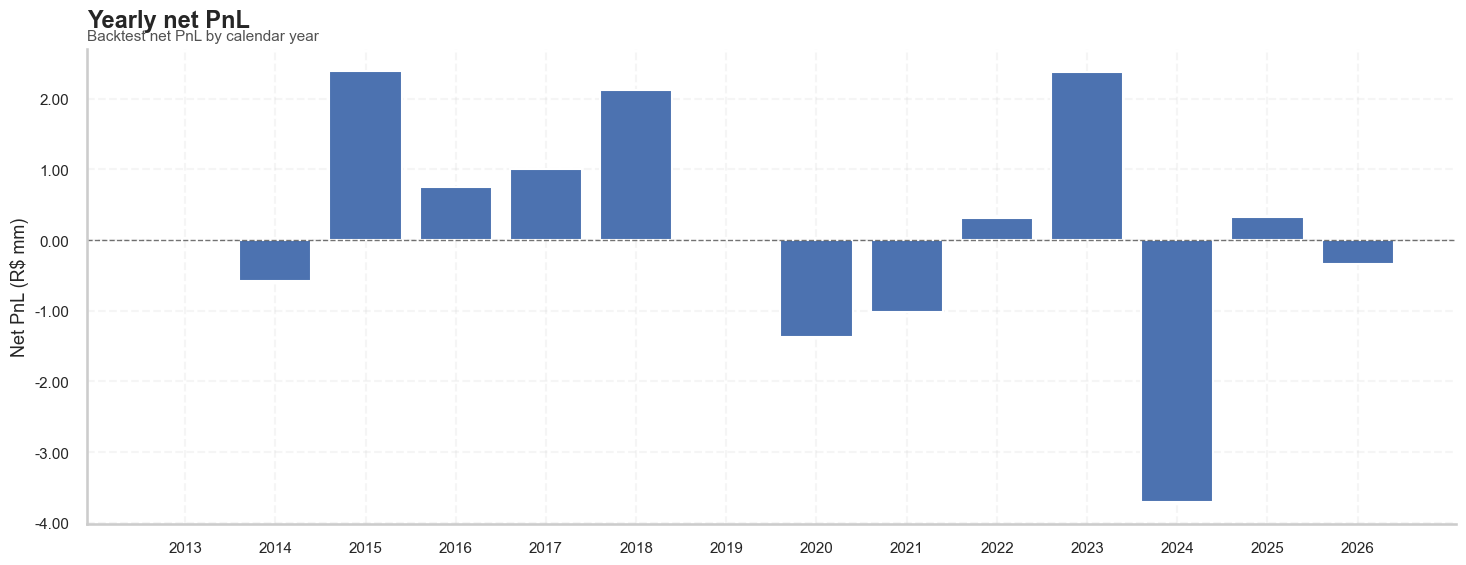

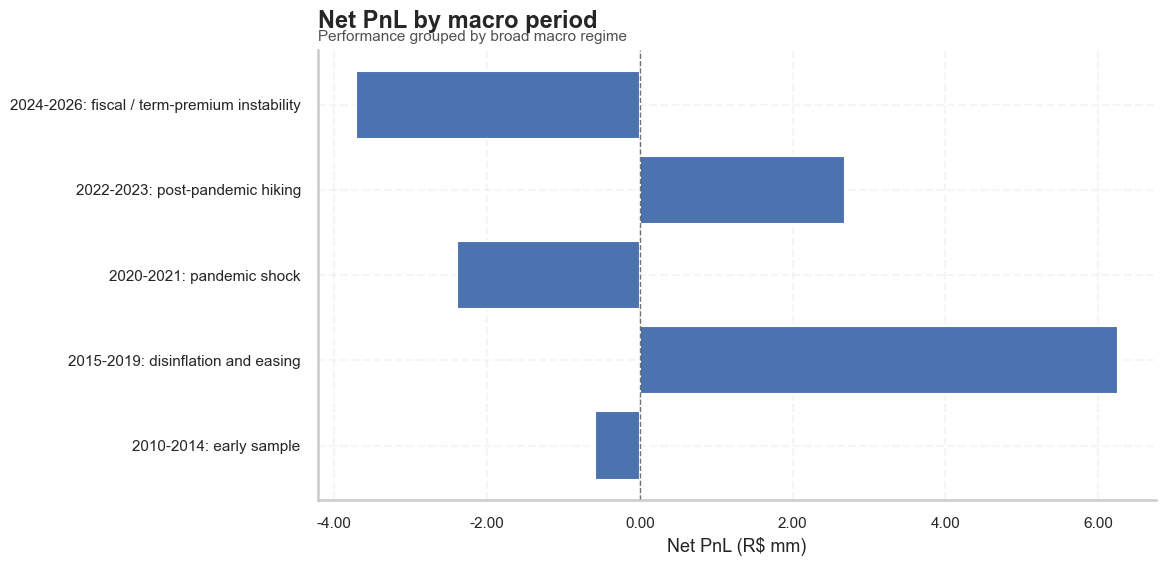


Saved analysis tables:
- c:\Projetos\estudo_curva\tables\tab_12_fair_value_zscore_period_metrics.tex
- c:\Projetos\estudo_curva\tables\tab_13_fair_value_zscore_period_pnl_decomposition.tex
- c:\Projetos\estudo_curva\tables\tab_14_fair_value_zscore_trade_duration_by_period.tex
- c:\Projetos\estudo_curva\tables\tab_15_fair_value_zscore_report_summary.tex
- c:\Projetos\estudo_curva\figures\fig_19_yearly_pnl_fair_value_zscore.png
- c:\Projetos\estudo_curva\figures\fig_20_period_pnl_fair_value_zscore.png


In [28]:
# ------------------------------------------------------------
# 15) Performance by macro/economic period
# ------------------------------------------------------------
PERIOD_ORDER = [
    "2010-2014: early sample",
    "2015-2019: disinflation and easing",
    "2020-2021: pandemic shock",
    "2022-2023: post-pandemic hiking",
    "2024-2026: fiscal / term-premium instability",
]

def assign_macro_period(dt):
    dt = pd.Timestamp(dt)

    if dt < pd.Timestamp("2015-01-01"):
        return "2010-2014: early sample"
    elif dt < pd.Timestamp("2020-01-01"):
        return "2015-2019: disinflation and easing"
    elif dt < pd.Timestamp("2022-01-01"):
        return "2020-2021: pandemic shock"
    elif dt < pd.Timestamp("2024-01-01"):
        return "2022-2023: post-pandemic hiking"
    else:
        return "2024-2026: fiscal / term-premium instability"

fair_df["macro_period"] = fair_df["date"].apply(assign_macro_period)
fair_df["macro_period"] = pd.Categorical(
    fair_df["macro_period"],
    categories=PERIOD_ORDER,
    ordered=True
)

period_rows = []

for period in PERIOD_ORDER:
    grp = fair_df[fair_df["macro_period"] == period].copy()
    if grp["net_pnl"].notna().sum() < 20:
        continue

    m = compute_perf_metrics(grp, pnl_col="net_pnl")

    period_rows.append({
        "period": period,
        "start_date": grp["date"].min().strftime("%Y-%m-%d"),
        "end_date": grp["date"].max().strftime("%Y-%m-%d"),
        **m
    })

period_table = pd.DataFrame(period_rows)

save_table(
    period_table,
    "tab_12_fair_value_zscore_period_metrics",
    index=False,
    rename_map={
        "period": "Period",
        "start_date": "Start",
        "end_date": "End",
        "nobs": "Obs.",
        "total_pnl": "Total PnL",
        "mean_daily_pnl": "Mean daily PnL",
        "vol_daily_pnl": "Daily vol",
        "annualized_pnl": "Annualized PnL",
        "annualized_vol": "Annualized vol",
        "sharpe": "Sharpe",
        "max_drawdown": "Max drawdown",
        "avg_abs_position": "Avg |position|",
        "annual_turnover": "Annual turnover",
        "hit_ratio": "Hit ratio",
    },
    float_fmt="%.4f"
)

print("\nPerformance by macro period:")
print(period_table)

# ------------------------------------------------------------
# 16) PnL decomposition by macro/economic period
# ------------------------------------------------------------
required_decomp_cols = {
    "gross_pnl",
    "carry_rolldown_pnl",
    "market_move_pnl",
    "transaction_cost",
    "net_pnl"
}

if required_decomp_cols.issubset(set(fair_df.columns)):
    period_decomp_rows = []

    for period in PERIOD_ORDER:
        grp = fair_df[fair_df["macro_period"] == period].copy()
        if grp["net_pnl"].notna().sum() < 20:
            continue

        gross = grp["gross_pnl"].sum()
        carry = grp["carry_rolldown_pnl"].sum()
        move = grp["market_move_pnl"].sum()
        cost = grp["transaction_cost"].sum()
        net = grp["net_pnl"].sum()

        period_decomp_rows.append({
            "period": period,
            "gross_pnl": gross,
            "carry_rolldown_pnl": carry,
            "market_move_pnl": move,
            "transaction_cost": cost,
            "net_pnl": net,
            "carry_share_gross": carry / gross if gross != 0 else np.nan,
            "market_share_gross": move / gross if gross != 0 else np.nan,
            "cost_share_gross": cost / gross if gross != 0 else np.nan,
        })

    period_decomp_table = pd.DataFrame(period_decomp_rows)

    save_table(
        period_decomp_table,
        "tab_13_fair_value_zscore_period_pnl_decomposition",
        index=False,
        rename_map={
            "period": "Period",
            "gross_pnl": "Gross PnL",
            "carry_rolldown_pnl": "Carry / rolldown",
            "market_move_pnl": "Market move",
            "transaction_cost": "Transaction cost",
            "net_pnl": "Net PnL",
            "carry_share_gross": "Carry / gross",
            "market_share_gross": "Move / gross",
            "cost_share_gross": "Cost / gross",
        },
        float_fmt="%.4f"
    )

    print("\nPnL decomposition by macro period:")
    print(period_decomp_table)

# ------------------------------------------------------------
# 17) Trade duration by macro/economic period
# ------------------------------------------------------------
if "trade_log" in locals() and len(trade_log) > 0:
    trade_log["entry_date"] = pd.to_datetime(trade_log["entry_date"])
    trade_log["exit_date"] = pd.to_datetime(trade_log["exit_date"])
    trade_log["macro_period"] = trade_log["entry_date"].apply(assign_macro_period)
    trade_log["macro_period"] = pd.Categorical(
        trade_log["macro_period"],
        categories=PERIOD_ORDER,
        ordered=True
    )

    trade_period_rows = []

    for period in PERIOD_ORDER:
        grp = trade_log[trade_log["macro_period"] == period].copy()
        if len(grp) == 0:
            continue

        trade_period_rows.append({
            "period": period,
            "number_of_trades": len(grp),
            "avg_holding_days": grp["holding_days"].mean(),
            "median_holding_days": grp["holding_days"].median(),
            "min_holding_days": grp["holding_days"].min(),
            "max_holding_days": grp["holding_days"].max(),
            "avg_calendar_days": grp["holding_calendar_days"].mean() if "holding_calendar_days" in grp.columns else np.nan,
            "pct_profitable_trades": (grp["net_pnl"] > 0).mean(),
            "avg_net_pnl_per_trade": grp["net_pnl"].mean(),
            "median_net_pnl_per_trade": grp["net_pnl"].median(),
        })

    trade_period_table = pd.DataFrame(trade_period_rows)

    save_table(
        trade_period_table,
        "tab_14_fair_value_zscore_trade_duration_by_period",
        index=False,
        rename_map={
            "period": "Period",
            "number_of_trades": "Trades",
            "avg_holding_days": "Avg holding days",
            "median_holding_days": "Median holding days",
            "min_holding_days": "Min holding days",
            "max_holding_days": "Max holding days",
            "avg_calendar_days": "Avg calendar days",
            "pct_profitable_trades": "Profitable trades",
            "avg_net_pnl_per_trade": "Avg net PnL / trade",
            "median_net_pnl_per_trade": "Median net PnL / trade",
        },
        float_fmt="%.2f"
    )

    print("\nTrade duration by macro period:")
    print(trade_period_table)

# ------------------------------------------------------------
# 18) Annual PnL plot
# ------------------------------------------------------------
if "yearly_table" in locals() and len(yearly_table) > 0:
    fig, ax = plt.subplots(figsize=(15, 6))

    plot_years = yearly_table.copy().sort_values("year")
    ax.bar(
        plot_years["year"].astype(str),
        plot_years["total_pnl"] / 1e6
    )

    ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
    ax.set_title("Yearly net PnL", loc="left", pad=16, fontweight="bold")
    add_subtitle(ax, "Backtest net PnL by calendar year")
    ax.set_ylabel("Net PnL (R$ mm)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_19_yearly_pnl_fair_value_zscore.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / "fig_19_yearly_pnl_fair_value_zscore.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# 19) Period PnL plot
# ------------------------------------------------------------
if "period_table" in locals() and len(period_table) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    plot_periods = period_table.copy()
    ax.barh(
        plot_periods["period"],
        plot_periods["total_pnl"] / 1e6
    )

    ax.axvline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
    ax.set_title("Net PnL by macro period", loc="left", pad=16, fontweight="bold")
    add_subtitle(ax, "Performance grouped by broad macro regime")
    ax.set_xlabel("Net PnL (R$ mm)")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_20_period_pnl_fair_value_zscore.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / "fig_20_period_pnl_fair_value_zscore.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# 20) Compact report-ready summary
# ------------------------------------------------------------
summary_rows = []

if "period_table" in locals() and len(period_table) > 0:
    best_period = period_table.sort_values("total_pnl", ascending=False).iloc[0]
    worst_period = period_table.sort_values("total_pnl", ascending=True).iloc[0]

    summary_rows.append({
        "metric": "Best macro period",
        "value": best_period["period"]
    })
    summary_rows.append({
        "metric": "Worst macro period",
        "value": worst_period["period"]
    })

if "trade_log" in locals() and len(trade_log) > 0:
    summary_rows.append({
        "metric": "Total trades",
        "value": f"{len(trade_log)}"
    })
    summary_rows.append({
        "metric": "Avg holding days",
        "value": f"{trade_log['holding_days'].mean():.1f}"
    })
    summary_rows.append({
        "metric": "Profitable trades",
        "value": f"{100 * (trade_log['net_pnl'] > 0).mean():.1f}%"
    })

summary_table = pd.DataFrame(summary_rows)

save_table(
    summary_table,
    "tab_15_fair_value_zscore_report_summary",
    index=False,
    rename_map={
        "metric": "Metric",
        "value": "Value"
    }
)

print("\nSaved analysis tables:")
print(f"- {TABLES_DIR / 'tab_12_fair_value_zscore_period_metrics.tex'}")
print(f"- {TABLES_DIR / 'tab_13_fair_value_zscore_period_pnl_decomposition.tex'}")
print(f"- {TABLES_DIR / 'tab_14_fair_value_zscore_trade_duration_by_period.tex'}")
print(f"- {TABLES_DIR / 'tab_15_fair_value_zscore_report_summary.tex'}")
print(f"- {FIG_DIR / 'fig_19_yearly_pnl_fair_value_zscore.png'}")
print(f"- {FIG_DIR / 'fig_20_period_pnl_fair_value_zscore.png'}")

        date  selic_target
0 2010-01-01          8.75
1 2010-01-02          8.75
2 2010-01-03          8.75
3 2010-01-04          8.75
4 2010-01-05          8.75
           date  selic_target
5916 2026-03-14          15.0
5917 2026-03-15          15.0
5918 2026-03-16          15.0
5919 2026-03-17          15.0
5920 2026-03-18          15.0
  start_date   end_date  cycle_type                  label
0 2010-04-29 2011-08-31  tightening  2010-2011: tightening
1 2011-09-01 2013-04-17      easing      2011-2013: easing
2 2013-04-18 2016-10-19  tightening  2013-2016: tightening
3 2016-10-20 2021-03-17      easing      2016-2021: easing
4 2021-03-18 2023-08-02  tightening  2021-2023: tightening
5 2023-08-03 2024-09-18      easing      2023-2024: easing
6 2024-09-19 2026-03-05  tightening  2024-2026: tightening
                   cycle  start_date    end_date  cycle_type  nobs  \
0      2011-2013: easing  2011-09-01  2013-04-17      easing    57   
1  2013-2016: tightening  2013-04-18  2016-10-

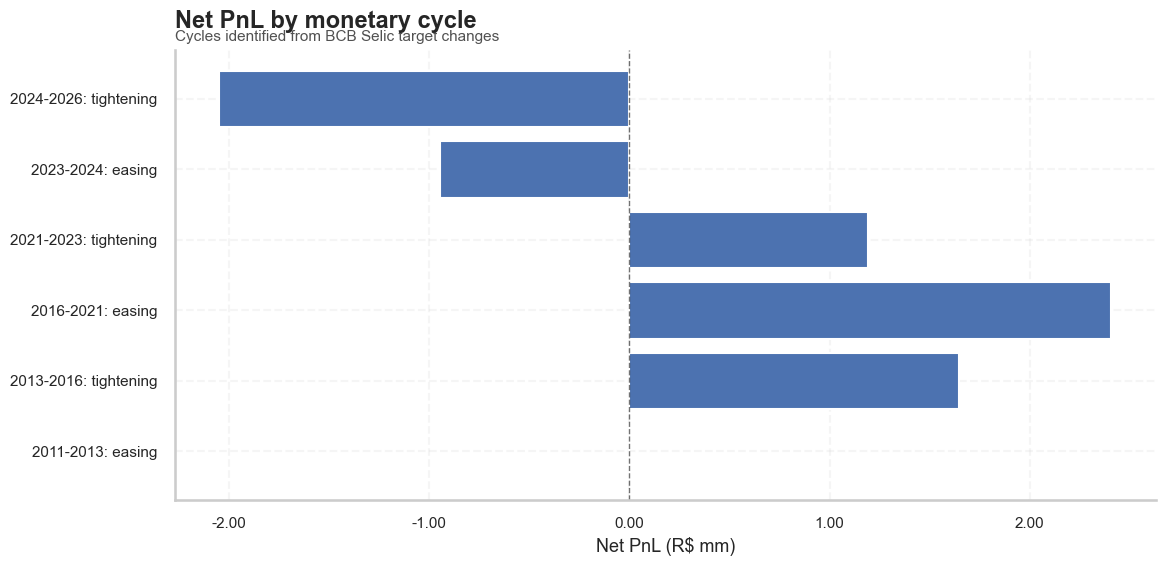

In [ ]:
# ------------------------------------------------------------
# Monetary cycles from official BCB Selic target (SGS 432)
# ------------------------------------------------------------
import requests
from io import StringIO

def fetch_sgs_series(series_id: int, start_date: str, end_date: str) -> pd.DataFrame:

    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_id}/dados"
        f"?formato=json&dataInicial={start_date}&dataFinal={end_date}"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()

    out = pd.DataFrame(data)
    out["data"] = pd.to_datetime(out["data"], format="%d/%m/%Y", errors="coerce")
    out["valor"] = pd.to_numeric(out["valor"], errors="coerce")
    out = out.dropna(subset=["data", "valor"]).sort_values("data").reset_index(drop=True)
    return out

# BCB / SGS:
# 432 = Meta Selic
selic_parts = [
    fetch_sgs_series(432, "01/01/2010", "31/12/2019"),
    fetch_sgs_series(432, "01/01/2020", "31/12/2026"),
]

selic_meta = pd.concat(selic_parts, ignore_index=True).drop_duplicates("data").sort_values("data").reset_index(drop=True)
selic_meta = selic_meta.rename(columns={"data": "date", "valor": "selic_target"})

print(selic_meta.head())
print(selic_meta.tail())

# ------------------------------------------------------------
# Identify change points in the Selic target
# ------------------------------------------------------------
selic_changes = selic_meta.copy()
selic_changes["delta"] = selic_changes["selic_target"].diff()
selic_changes = selic_changes[selic_changes["delta"].notna() & (selic_changes["delta"] != 0)].copy()

def classify_cycle(delta):
    if delta > 0:
        return "tightening"
    elif delta < 0:
        return "easing"
    return "hold"

selic_changes["cycle_type"] = selic_changes["delta"].apply(classify_cycle)

# Build cycle intervals:
# from each change date until the day before the next change date
cycle_rows = []

for i in range(len(selic_changes)):
    start_date = selic_changes.iloc[i]["date"]
    cycle_type = selic_changes.iloc[i]["cycle_type"]
    delta = selic_changes.iloc[i]["delta"]

    if i < len(selic_changes) - 1:
        end_date = selic_changes.iloc[i + 1]["date"] - pd.Timedelta(days=1)
    else:
        end_date = fair_df["date"].max()

    cycle_rows.append({
        "cycle_id": i + 1,
        "start_date": start_date,
        "end_date": end_date,
        "cycle_type": cycle_type,
        "delta_start_bp": delta * 100,   # Selic change in bp
        "selic_start": selic_changes.iloc[i]["selic_target"],
    })

cycles_df = pd.DataFrame(cycle_rows)

merged_cycles = []
if len(cycles_df) > 0:
    current = cycles_df.iloc[0].to_dict()

    for i in range(1, len(cycles_df)):
        row = cycles_df.iloc[i].to_dict()

        contiguous = (row["start_date"] <= current["end_date"] + pd.Timedelta(days=2))
        same_type = (row["cycle_type"] == current["cycle_type"])

        if contiguous and same_type:
            current["end_date"] = row["end_date"]
            current["delta_start_bp"] += row["delta_start_bp"]
        else:
            merged_cycles.append(current)
            current = row

    merged_cycles.append(current)

monetary_cycles = pd.DataFrame(merged_cycles).reset_index(drop=True)

# Create readable labels
monetary_cycles["label"] = monetary_cycles.apply(
    lambda x: f"{x['start_date'].year}-{x['end_date'].year}: {x['cycle_type']}",
    axis=1
)

print(monetary_cycles[["start_date", "end_date", "cycle_type", "label"]])

# ------------------------------------------------------------
# Assign each backtest observation to a monetary cycle
# ------------------------------------------------------------
def assign_cycle(dt, cycle_table):
    dt = pd.Timestamp(dt)
    for _, row in cycle_table.iterrows():
        if row["start_date"] <= dt <= row["end_date"]:
            return row["label"]
    return np.nan

fair_df["monetary_cycle"] = fair_df["date"].apply(lambda x: assign_cycle(x, monetary_cycles))

# ------------------------------------------------------------
# Performance by monetary cycle
# ------------------------------------------------------------
cycle_perf_rows = []

for _, cyc in monetary_cycles.iterrows():
    label = cyc["label"]
    grp = fair_df[fair_df["monetary_cycle"] == label].copy()

    if grp["net_pnl"].notna().sum() < 20:
        continue

    m = compute_perf_metrics(grp, pnl_col="net_pnl")

    cycle_perf_rows.append({
        "cycle": label,
        "start_date": cyc["start_date"].strftime("%Y-%m-%d"),
        "end_date": cyc["end_date"].strftime("%Y-%m-%d"),
        "cycle_type": cyc["cycle_type"],
        **m
    })

cycle_perf_table = pd.DataFrame(cycle_perf_rows)

save_table(
    cycle_perf_table,
    "tab_16_fair_value_zscore_monetary_cycle_metrics",
    index=False,
    rename_map={
        "cycle": "Monetary cycle",
        "start_date": "Start",
        "end_date": "End",
        "cycle_type": "Type",
        "nobs": "Obs.",
        "total_pnl": "Total PnL",
        "mean_daily_pnl": "Mean daily PnL",
        "vol_daily_pnl": "Daily vol",
        "annualized_pnl": "Annualized PnL",
        "annualized_vol": "Annualized vol",
        "sharpe": "Sharpe",
        "max_drawdown": "Max drawdown",
        "avg_abs_position": "Avg |position|",
        "annual_turnover": "Annual turnover",
        "hit_ratio": "Hit ratio",
    },
    float_fmt="%.4f"
)

print(cycle_perf_table)

# ------------------------------------------------------------
# Plot: Net PnL by monetary cycle
# ------------------------------------------------------------
plot_cycles = cycle_perf_table.copy()
plot_cycles["total_pnl_mm"] = plot_cycles["total_pnl"] / 1e6

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(plot_cycles["cycle"], plot_cycles["total_pnl_mm"])

ax.axvline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
ax.set_title("Net PnL by monetary cycle", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Cycles identified from BCB Selic target changes")
ax.set_xlabel("Net PnL (R$ mm)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}"))

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_21_pnl_by_monetary_cycle.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_21_pnl_by_monetary_cycle.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)